# ETL

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_errors = pd.read_csv("https://raw.githubusercontent.com/No-Country-simulation/S08-26-EQUIPO-24/refs/heads/main/data/raw/PdM_errors.csv")
df_failures = pd.read_csv("https://raw.githubusercontent.com/No-Country-simulation/S08-26-EQUIPO-24/refs/heads/main/data/raw/PdM_failures.csv")
df_machines = pd.read_csv("https://raw.githubusercontent.com/No-Country-simulation/S08-26-EQUIPO-24/refs/heads/main/data/raw/PdM_machines.csv")
df_maint = pd.read_csv("https://raw.githubusercontent.com/No-Country-simulation/S08-26-EQUIPO-24/refs/heads/main/data/raw/PdM_maint.csv")
df_telemetry = pd.read_csv("https://raw.githubusercontent.com/No-Country-simulation/S08-26-EQUIPO-24/refs/heads/main/data/raw/PdM_telemetry.csv")

In [ ]:
df_errors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3919 entries, 0 to 3918
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   datetime   3919 non-null   object
 1   machineID  3919 non-null   int64 
 2   errorID    3919 non-null   object
dtypes: int64(1), object(2)
memory usage: 92.0+ KB


In [ ]:
df_errors.head()

,datetime,machineID,errorID
0,2015-01-03 07:00:00,1,error1
1,2015-01-03 20:00:00,1,error3
2,2015-01-04 06:00:00,1,error5
3,2015-01-10 15:00:00,1,error4
4,2015-01-22 10:00:00,1,error4


In [ ]:
df_failures.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 761 entries, 0 to 760
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   datetime   761 non-null    object
 1   machineID  761 non-null    int64 
 2   failure    761 non-null    object
dtypes: int64(1), object(2)
memory usage: 18.0+ KB


In [ ]:
df_machines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   machineID  100 non-null    int64 
 1   model      100 non-null    object
 2   age        100 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 2.5+ KB


In [ ]:
df_maint.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   datetime   3286 non-null   object
 1   machineID  3286 non-null   int64 
 2   comp       3286 non-null   object
dtypes: int64(1), object(2)
memory usage: 77.1+ KB


In [ ]:
df_telemetry.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 876100 entries, 0 to 876099
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   datetime   876100 non-null  object 
 1   machineID  876100 non-null  int64  
 2   volt       876100 non-null  float64
 3   rotate     876100 non-null  float64
 4   pressure   876100 non-null  float64
 5   vibration  876100 non-null  float64
dtypes: float64(4), int64(1), object(1)
memory usage: 40.1+ MB


In [ ]:
df_errors['datetime'] = pd.to_datetime(df_errors['datetime'])

In [ ]:
df_failures['datetime'] = pd.to_datetime(df_failures['datetime'])

In [ ]:
df_maint['datetime'] = pd.to_datetime(df_maint['datetime'])

In [ ]:
df_telemetry['datetime'] = pd.to_datetime(df_telemetry['datetime'])

In [ ]:
print(df_errors.duplicated().sum())
print(df_failures.duplicated().sum())
print(df_machines.duplicated().sum())
print(df_maint.duplicated().sum())
print(df_telemetry.duplicated().sum())

0
0
0
0
0


# EDA

In [ ]:
df_machines.describe()

,machineID,age
count,100.000000,100.000000
mean,50.500000,11.330000
std,29.011492,5.856974
min,1.000000,0.000000
25%,25.750000,6.750000
50%,50.500000,12.000000
75%,75.250000,16.000000
max,100.000000,20.000000


In [ ]:
df_telemetry.describe()

,datetime,machineID,volt,rotate,pressure,vibration
count,876100,876100.000000,876100.000000,876100.000000,876100.000000,876100.000000
mean,2015-07-02 18:00:00,50.500000,170.777736,446.605119,100.858668,40.385007
min,2015-01-01 06:00:00,1.000000,97.333604,138.432075,51.237106,14.877054
25%,2015-04-02 12:00:00,25.750000,160.304927,412.305714,93.498181,36.777299
50%,2015-07-02 18:00:00,50.500000,170.607338,447.558150,100.425559,40.237247
75%,2015-10-02 00:00:00,75.250000,181.004493,482.176600,107.555231,43.784938
max,2016-01-01 06:00:00,100.000000,255.124717,695.020984,185.951998,76.791072
std,NaN,28.866087,15.509114,52.673886,11.048679,5.370361


## ¿Cuántas máquinas hay?

In [ ]:
df_machines["machineID"].nunique()

100

In [ ]:
df_machines["model"].value_counts()

,count
model,
model3,35
model4,32
model2,17
model1,16


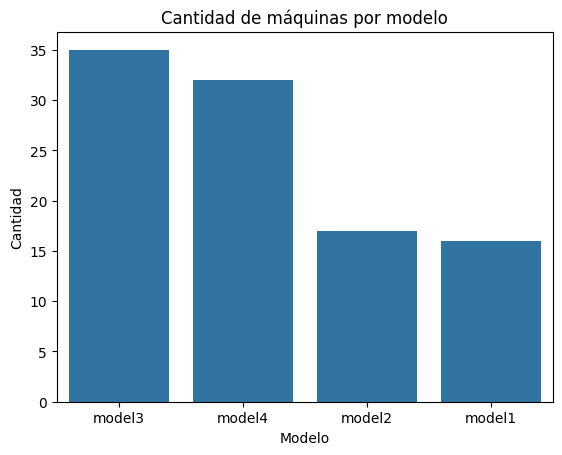

In [ ]:
sns.countplot(data=df_machines, x="model")

plt.title("Cantidad de máquinas por modelo")
plt.xlabel("Modelo")
plt.ylabel("Cantidad")

plt.show()

## Edad de las máquinas

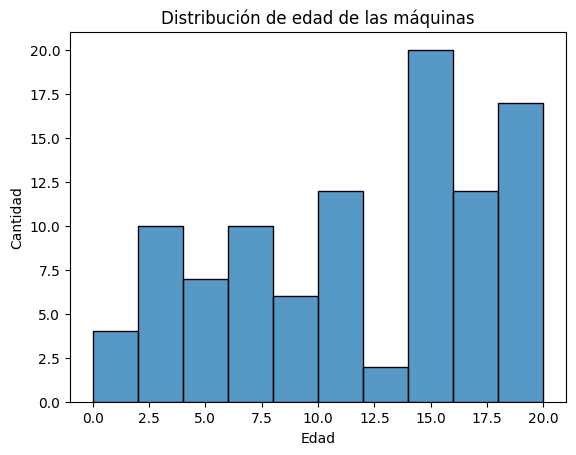

In [ ]:
# Graficamos
sns.histplot(data=df_machines, x="age", bins=10)

plt.title("Distribución de edad de las máquinas")
plt.xlabel("Edad")
plt.ylabel("Cantidad")

plt.show()

## Análisis de arrores

In [ ]:
df_errors.head()

,datetime,machineID,errorID
0,2015-01-03 07:00:00,1,error1
1,2015-01-03 20:00:00,1,error3
2,2015-01-04 06:00:00,1,error5
3,2015-01-10 15:00:00,1,error4
4,2015-01-22 10:00:00,1,error4


In [ ]:
len(df_errors)

3919

In [ ]:
errors_machine = df_errors["machineID"].value_counts()

errors_machine.head(10)

,count
machineID,
22,60
99,54
78,54
15,51
81,51
49,51
63,50
79,50
88,50


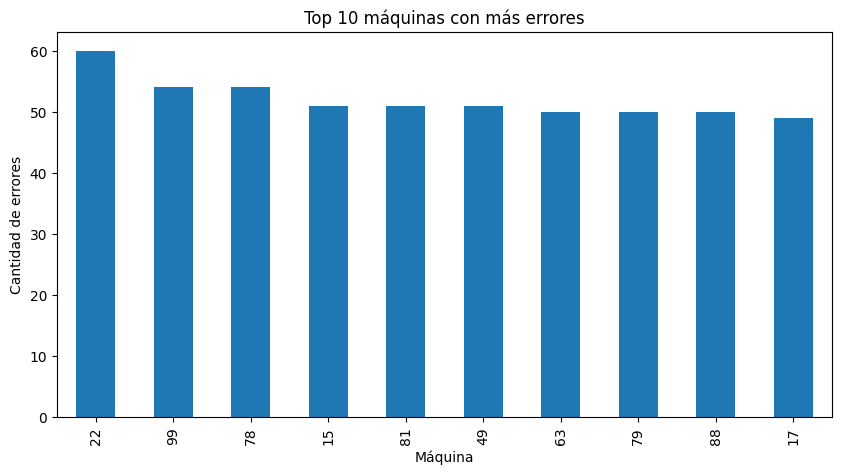

In [ ]:
# Graficamos
errors_machine.head(10).plot(kind="bar", figsize=(10,5))

plt.title("Top 10 máquinas con más errores")
plt.xlabel("Máquina")
plt.ylabel("Cantidad de errores")

plt.show()

## Análisis de fallas

In [ ]:
failures_machine = df_failures["machineID"].value_counts()

failures_machine.head(10)

,count
machineID,
99,19
98,16
22,15
17,15
83,14
37,14
20,13
13,13
16,13


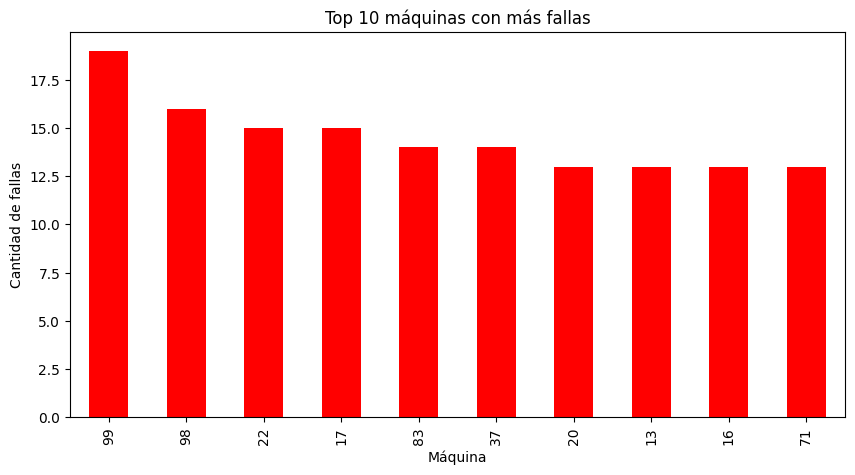

In [ ]:
# Graficamos
failures_machine.head(10).plot(kind="bar", figsize=(10,5), color="red")

plt.title("Top 10 máquinas con más fallas")
plt.xlabel("Máquina")
plt.ylabel("Cantidad de fallas")

plt.show()

## Análisis de los tipos de falla

In [ ]:
df_failures["failure"].value_counts()

,count
failure,
comp2,259
comp1,192
comp4,179
comp3,131


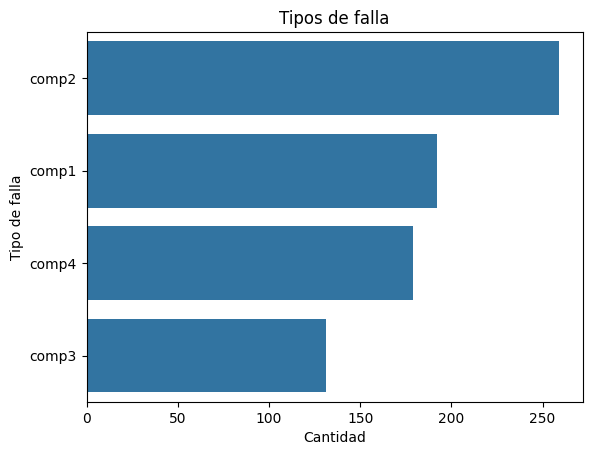

In [ ]:
# Graficamos
sns.countplot(data=df_failures, y="failure", order=df_failures["failure"].value_counts().index)

plt.title("Tipos de falla")
plt.xlabel("Cantidad")
plt.ylabel("Tipo de falla")

plt.show()

## Análisis de mantenimientos

In [ ]:
maint_machine = df_maint["machineID"].value_counts()

maint_machine.head(10)

,count
machineID,
66,39
70,39
68,39
24,38
42,38
27,38
14,38
84,38
10,38


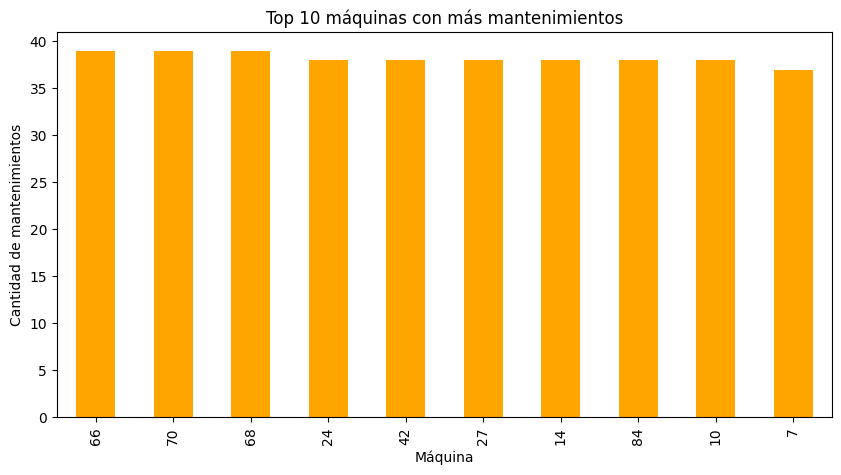

In [ ]:
# Graficamos
maint_machine.head(10).plot(kind="bar", figsize=(10,5), color="orange")

plt.title("Top 10 máquinas con más mantenimientos")
plt.xlabel("Máquina")
plt.ylabel("Cantidad de mantenimientos")

plt.show()

## Análisis de sensores

In [ ]:
df_telemetry.head()

,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511


In [ ]:
df_telemetry.describe()

,datetime,machineID,volt,rotate,pressure,vibration
count,876100,876100.000000,876100.000000,876100.000000,876100.000000,876100.000000
mean,2015-07-02 18:00:00,50.500000,170.777736,446.605119,100.858668,40.385007
min,2015-01-01 06:00:00,1.000000,97.333604,138.432075,51.237106,14.877054
25%,2015-04-02 12:00:00,25.750000,160.304927,412.305714,93.498181,36.777299
50%,2015-07-02 18:00:00,50.500000,170.607338,447.558150,100.425559,40.237247
75%,2015-10-02 00:00:00,75.250000,181.004493,482.176600,107.555231,43.784938
max,2016-01-01 06:00:00,100.000000,255.124717,695.020984,185.951998,76.791072
std,NaN,28.866087,15.509114,52.673886,11.048679,5.370361


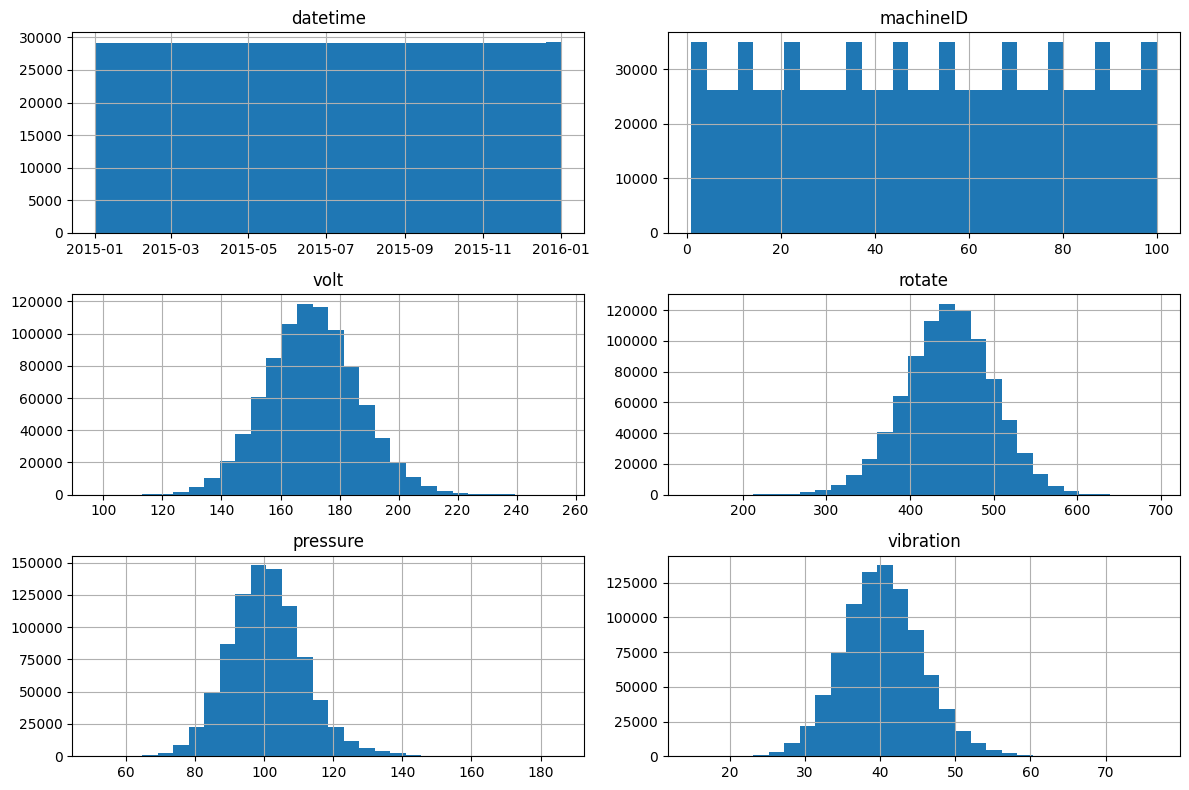

In [ ]:
# Graficamos
df_telemetry.hist(figsize=(12,8), bins=30)

plt.tight_layout()
plt.show()

## Correlación de sensores

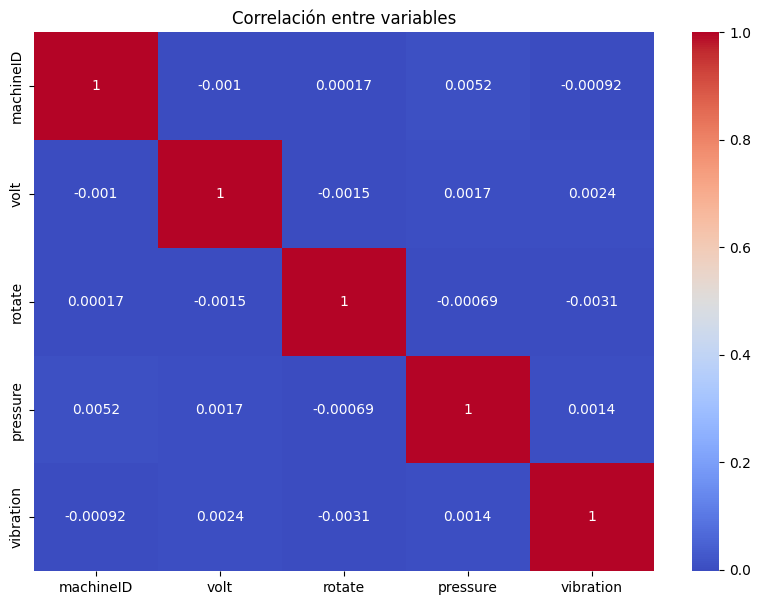

In [ ]:
plt.figure(figsize=(10,7))

sns.heatmap(df_telemetry.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlación entre variables")

plt.show()

## Relación de errores y fallas

In [ ]:
errores = df_errors.groupby("machineID").size()

fallas = df_failures.groupby("machineID").size()

In [ ]:
df_resumen = pd.DataFrame({"errores": errores, "fallas": fallas}).fillna(0)

df_resumen.head()

,errores,fallas
machineID,,
1,35,7.0
2,28,4.0
3,39,5.0
4,31,6.0
5,38,7.0


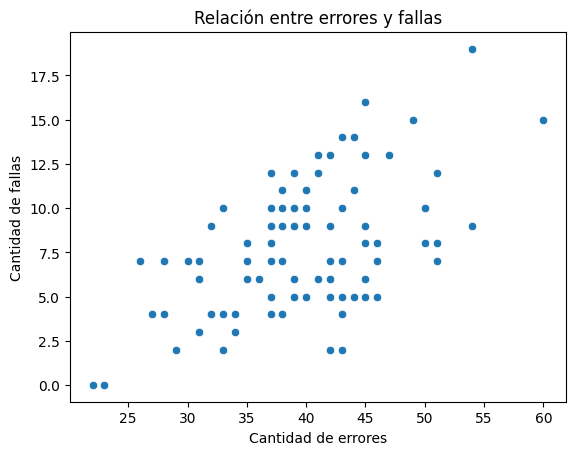

In [ ]:
# Graficamos
sns.scatterplot(data=df_resumen, x="errores", y="fallas")

plt.title("Relación entre errores y fallas")
plt.xlabel("Cantidad de errores")
plt.ylabel("Cantidad de fallas")

plt.show()